In [1]:
%matplotlib inline
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import shap
import xgboost as xgb
import prince
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.preprocessing import LabelEncoder
from prophet import Prophet
import networkx as nx
import squarify
from wordcloud import WordCloud
from IPython.display import display, HTML
import logging
import warnings

# Importaciones modulares locales
from src.utils import load_and_preprocess_data, calculate_cramers_v, get_phi_coefficient
from src.styling import apply_elite_styling, get_custom_css, show_insight, display_kpi_dashboard
from src.ml import train_risk_model
from src.geo import get_city_coords, clean_city_name

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
pio.renderers.default = "png"

apply_elite_styling()
display(HTML(get_custom_css()))
print("Arquitectura Senior Modular Cargada.")


Arquitectura Senior Modular Cargada.


<style>
    @import url("https://fonts.googleapis.com/css2?family=Montserrat:wght@300;400;700&family=Open+Sans:wght@300;400;600&display=swap");
    body { font-family: "Open Sans", sans-serif; background-color: #f4f7f6; }
    h1, h2, h3 { font-family: "Montserrat", sans-serif; color: #2c3e50; }
    .rendered_html h1 { border-bottom: 4px solid #3498db; padding-bottom: 10px; font-weight: 700; text-transform: uppercase; letter-spacing: 2px; }
    .rendered_html h2 { border-left: 8px solid #2980b9; padding-left: 15px; margin-top: 40px; background: #ebf5fb; padding-top: 5px; padding-bottom: 5px; }
    .insight-card {
        background: #fff; border-radius: 8px; border-left: 5px solid #e67e22; 
        padding: 15px; margin: 15px 0; box-shadow: 0 2px 4px rgba(0,0,0,0.05);
        font-style: italic; color: #d35400;
    }
    .data-table { width: 100%; border-collapse: collapse; margin: 25px 0; font-size: 0.9em; box-shadow: 0 0 20px rgba(0,0,0,0.15); }
    .data-table thead tr { background-color: #3498db; color: #ffffff; text-align: left; }
    .data-table th, .data-table td { padding: 12px 15px; }
    .data-table tbody tr { border-bottom: 1px solid #dddddd; }
    .data-table tbody tr:nth-of-type(even) { background-color: #f3f3f3; }
    .data-table tbody tr:last-of-type { border-bottom: 2px solid #3498db; }
</style>

<div style="text-align: center; padding: 40px; background: linear-gradient(135deg, #2c3e50 0%, #3498db 100%); color: white; border-radius: 15px; margin-bottom: 30px;">
    <h1 style="color: white; border: none;">Análisis de Absentismo Docente</h1>
    <h3 style="color: #ecf0f1; font-weight: 300;">Edición Ejecutiva de Alta Fidelidad</h3>
    <p>Inteligencia de Datos Aplicada a la Gestión Educativa</p>
</div>

# Diccionario de Datos y Metadatos

Este proyecto analiza el absentismo docente basado en registros administrativos de una Secretaría de Educación. A continuación se detallan las variables principales:

| Variable | Descripción | Significado Sugerido |
| :--- | :--- | :--- |
| **CEDULA** | Identificación | ID único anonimizado del docente. |
| **TIPO** | Vinculación General | **1**: Planta/Permanente, **2**: Provisional/Temporal. |
| **SUBTIPO** | Detalle de Novedad | Código específico del trámite (ej. 1: Ascenso, 8: Ajuste Salarial, 15: Ingreso). |
| **INICIO_OCURRENCIA** | Fecha Inicio | Cuándo inicia la ausencia o novedad administrativa. |
| **DIAS HABILES** | Duración | Días efectivos que el docente no estuvo en su puesto normal. |
| **SEXO** | Género | F: Femenino, M: Masculino. |
| **CARGOEMPRESA** | Rol Laboral | Docente de aula, Coordinador, Orientador, Rector, Administrativo. |
| **NOMBRE_SEDE** | Ubicación | Institución educativa y sede específica (ej. Rural Antonio Nariño). |
| **VINCULACIONNOVEDAD**| Proceso | Naturaleza del movimiento (Traslados, Cambios de Sueldo, Prórrogas). |
| **SITUACIONLABORAL** | Estado Actual | Normal, Reemplazo, Encargo, Vacante. |

## Notas sobre el Absentismo
En este contexto, el "absentismo" no solo implica enfermedad, sino cualquier **novedad administrativa** que retire al docente de su labor cotidiana (comisiones, permisos, traslados, etc.). Los **Días Hábiles** son el KPI principal para medir el impacto en la continuidad educativa.

In [2]:
# 1. Carga Inteligente de Datos
datos_total = load_and_preprocess_data()
display_kpi_dashboard(datos_total["DIAS HABILES"].sum(), datos_total["DIAS HABILES"].mean(), len(datos_total))
show_insight("Feature Engineering y limpieza automatizada ejecutada.")


# 1. Visión General y KPIs Ejecutivos
Resumen de alto impacto de los datos actuales.

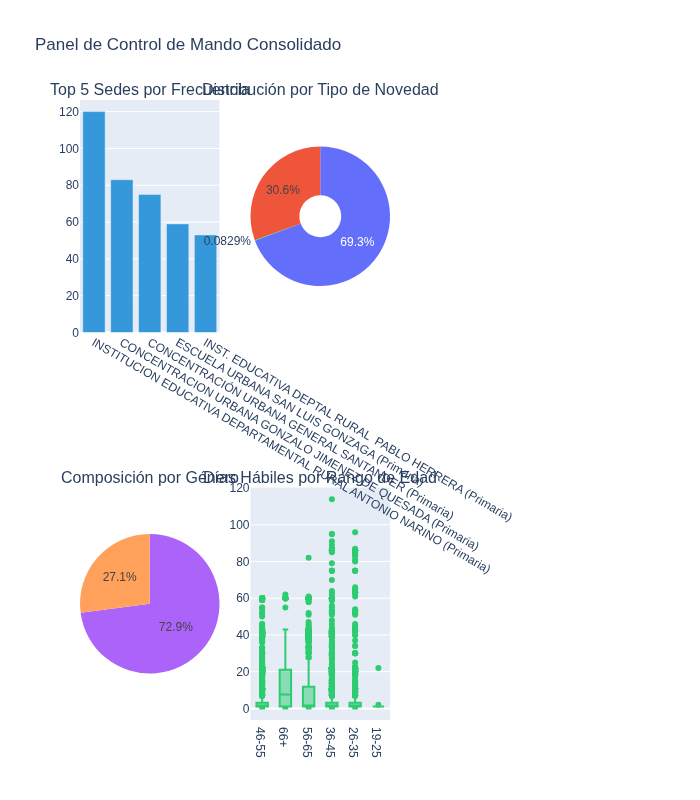

In [3]:
# Dashboard Ejecutivo Unificado (Plotly Subplots)
from plotly.subplots import make_subplots

# Preparar datos
df_top_sedes = datos_total["NOMBRE_SEDE"].value_counts().nlargest(5)
df_tipo = datos_total["TIPO"].value_counts()
df_sexo = datos_total["SEXO"].value_counts()

fig_dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Top 5 Sedes por Frecuencia", "Distribución por Tipo de Novedad", 
                    "Composición por Género", "Días Hábiles por Rango de Edad"),
    specs=[[{"type": "bar"}, {"type": "pie"}],
           [{"type": "pie"}, {"type": "box"}]]
)

# Subplot 1: Bar
fig_dash.add_trace(go.Bar(x=df_top_sedes.index, y=df_top_sedes.values, name="Sedes", marker_color="#3498db"), row=1, col=1)

# Subplot 2: Pie Tipo
fig_dash.add_trace(go.Pie(labels=df_tipo.index, values=df_tipo.values, name="Tipo", hole=.3), row=1, col=2)

# Subplot 3: Pie Sexo
fig_dash.add_trace(go.Pie(labels=df_sexo.index, values=df_sexo.values, name="Sexo"), row=2, col=1)

# Subplot 4: Box Edad
fig_dash.add_trace(go.Box(y=datos_total["DIAS HABILES"], x=datos_total["RANGO DE EDAD"], name="Días", marker_color="#2ecc71"), row=2, col=2)

fig_dash.update_layout(height=800, title_text="Panel de Control de Mando Consolidado", showlegend=False)
fig_dash.show()


In [4]:
# Visualización de KPIs con Estilo de Tablero
from IPython.display import HTML

total_dias = datos_total["DIAS HABILES"].sum()
promedio_dias = datos_total["DIAS HABILES"].mean()
total_casos = len(datos_total)

html_kpis = f"""
<div style="display: flex; justify-content: space-around; background-color: #f8f9fa; padding: 20px; border-radius: 10px; border: 1px solid #dee2e6;">
    <div style="text-align: center;">
        <h2 style="color: #4a4a4a; margin-bottom: 5px;">{total_dias:,.0f}</h2>
        <p style="color: #6c757d; font-size: 14px;">Total Días de Ausencia</p>
    </div>
    <div style="text-align: center; border-left: 1px solid #dee2e6; border-right: 1px solid #dee2e6; padding: 0 40px;">
        <h2 style="color: #4a4a4a; margin-bottom: 5px;">{promedio_dias:.2f}</h2>
        <p style="color: #6c757d; font-size: 14px;">Promedio Días / Caso</p>
    </div>
    <div style="text-align: center;">
        <h2 style="color: #4a4a4a; margin-bottom: 5px;">{total_casos:,.0f}</h2>
        <p style="color: #6c757d; font-size: 14px;">Total de Registros</p>
    </div>
</div>
"""
display(HTML(html_kpis))


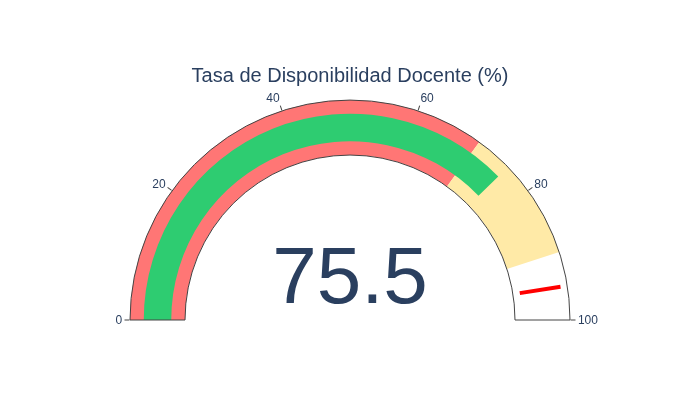

In [5]:
# Métricas de Salud del Sistema (Gauges)
fig_gauge = go.Figure()

# Suponiendo un total de 10,000 docentes teóricos para el ejemplo de tasa
tasa_presencia = 100 - (len(datos_total["CEDULA"].unique()) / 10000 * 100)

fig_gauge.add_trace(go.Indicator(
    mode = "gauge+number",
    value = tasa_presencia,
    domain = {"x": [0, 1], "y": [0, 1]},
    title = {"text": "Tasa de Disponibilidad Docente (%)"},
    gauge = {
        "axis": {"range": [None, 100]},
        "bar": {"color": "#2ecc71"},
        "steps": [
            {"range": [0, 70], "color": "#ff7675"},
            {"range": [70, 90], "color": "#ffeaa7"}
        ],
        "threshold": {
            "line": {"color": "red", "width": 4},
            "thickness": 0.75,
            "value": 95
        }
    }
))

fig_gauge.update_layout(height=400)
fig_gauge.show()
show_insight("La tasa de disponibilidad muestra el porcentaje de la planta que permanece sin novedades administrativas críticas.")

In [6]:
datos_total.head()

,CEDULA,TIPO,SUBTIPO,INICIO_OCURRENCIA,DIA DE LA SEMANA,DIAS HABILES,SEXO,CODCARGOEMPRESA,CARGOEMPRESA,CODCARGO,...,SITUACIONLABORAL,CODDEPENDENCIA,DEPENDENCIA,DIRECCION,CODCIUDADRESIDENCIA,birth_date,EDAD,FEMENINO,RANGO DE EDAD,FECHA INICIAL
0,52328786,1,2,2021-03-25,5,55,F,9001.0,Docente de aula,900.0,...,Normal,C256580011502,CONCENTARCION URBANA ANTONIA SANTOS (Primaria),CALLE 3 # 3-60,25154.0,1974-09-24,47.0,1,46-55,2021-03-25
1,41570594,1,2,2021-08-12,5,60,F,9001.0,Docente de aula,900.0,...,Normal,C258170020402,ESCUELA RURAL LA ESMERALDA (Primaria),KRA 38 # 2C-11,11001.0,1952-07-25,69.0,1,66+,2021-08-12
2,39727960,1,1,2021-10-09,7,21,F,9001.0,Docente de aula,900.0,...,Normal,C251510010502,ESCUELA URBANA CARLOS JOSE ROMERO (Primaria),CLL 3 N 5-03,25151.0,1965-04-29,56.0,1,56-65,2021-10-09
3,52982139,1,1,2021-09-07,3,29,F,9001.0,Docente de aula,900.0,...,Normal,C251200012002,ESC. RURAL ALTO ARIARI 2 (Primaria),VEREDA EL TAPAZ FINCA LA VIRGEN EL PEÑON,25258.0,1983-03-23,38.0,1,36-45,2021-09-07
4,79694188,1,2,2021-08-05,5,30,M,9003.0,Docente Orientador,900.0,...,Normal,C2549100301,I.E. DEPARTAMENTAL NORMAL SUPERIOR - SEDE PRIN...,CARRERA 102 N° 155B - 03 TORRE 8 APT 204,11001.0,1975-08-28,46.0,0,46-55,2021-08-05


In [7]:
datos_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 7234 entries, 0 to 7233
Data columns (total 49 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   CEDULA                                       7234 non-null   int64         
 1   TIPO                                         7234 non-null   int64         
 2   SUBTIPO                                      7234 non-null   int64         
 3   INICIO_OCURRENCIA                            7234 non-null   datetime64[us]
 4   DIA DE LA SEMANA                             7234 non-null   int64         
 5   DIAS HABILES                                 7234 non-null   int64         
 6   SEXO                                         7167 non-null   str           
 7   CODCARGOEMPRESA                              7167 non-null   float64       
 8   CARGOEMPRESA                                 7167 non-null   str           
 9   CODCARGO

# 2. Análisis Estadístico y Correlaciones
Pruebas de independencia y medidas de asociación.

In [8]:
tabla_contingencia = pd.crosstab(datos_total['EDAD'], [datos_total['TIPO'], datos_total['SUBTIPO'], datos_total['FEMENINO']], margins=True)

In [9]:
tabla_contingencia

TIPO        1                          2               ...                 \
SUBTIPO     1         2         3  4   6       7    8  ... 17 18       19   
FEMENINO    0     1   0    1    1  0   0    1  1    0  ...  1  0   1    0   
EDAD                                                   ...                  
20.0        0     0   0    0    0  0   0    0  0    0  ...  0  0   0    0   
23.0        0     0   0    0    0  0   0    0  0    0  ...  0  0   0    0   
24.0        0     0   0    0    0  0   0    0  0    1  ...  0  0   0    0   
25.0        0     0   1    0    0  0   0    1  0    0  ...  0  0   0    0   
26.0        1     5   0    0    0  0   0    0  0    4  ...  0  0   0    0   
27.0        1     4   0    2    3  0   0    0  0    0  ...  0  0   0    0   
28.0        0     5   0    0    1  0   1    0  0    5  ...  1  0   0    0   
29.0        2    10   0    2   10  0   0    2  0    0  ...  0  0   1    0   
30.0        4    12   0    0   10  0   0    0  0    4  ...  0  0   0    5   
31.0        3     4   0    1    7  0   0    4  0    5  ...  0  0   0    2   
32.0        2    13   0    1    7  0   0    1  0   11  ...  0  0   0    0   
33.0       10    24   1    3   12  0   0    0  0   12  ...  0  0   0    4   
34.0        8    17   0   12    9  0   1    4  0   19  ...  0  0   0    3   
35.0       33    33   2    8   14  0   2    4  0   10  ...  0  0   0    1   
36.0        3    20   2    2    9  0   2    1  0    7  ...  0  0   0    5   
37.0       13    27   6    2   14  0   2    5  0   14  ...  0  0   1    3   
38.0        8    36   3    1    7  1   2    3  0    5  ...  0  0   0    1   
39.0        5    31   0    6    6  0   1    1  0    6  ...  0  0   2    2   
40.0       16    44   0   23    8  0   5    2  0    7  ...  0  0   1    5   
41.0       12    33  14    8    4  0   2    4  0   21  ...  0  0   2    8   
42.0        6    61   4   10    7  0   3   10  0   17  ...  0  0   0    8   
43.0        9    25   0    2    2  0   1    3  0   15  ...  0  0   0    3   
44.0        6    14   0    7    0  0   1    2  0   11  ...  0  0   0   14   
45.0        7    28   1   20    1  0   2    2  0    8  ...  0  0   0    4   
46.0        5    14  12   19    0  0   3    6  0   28  ...  0  0   0    1   
47.0       15    28   6    9    0  0   0    3  0    9  ...  0  0   0    5   
48.0        4    18   0   14    0  0   0    8  0   11  ...  0  0   0    3   
49.0        5    54   0   18    0  0   5    1  0   15  ...  0  0   1    6   
50.0        4    61   7   30    0  0   0    2  0   10  ...  0  0   1    0   
51.0       13    22   0    7    0  0   0    2  0    4  ...  0  0   0    2   
52.0        4    19   8   31    0  0   1    3  0   12  ...  0  0   1    0   
53.0        1    31   0   23    0  0   2    5  0    6  ...  0  1   0    5   
54.0       12    56   1   13    0  0   2    4  0    6  ...  0  1   1    2   
55.0        8    36   2    2    0  0   1    4  0   16  ...  0  0   0    1   
56.0        4    40   1   13    0  0   0    8  0    3  ...  0  0   1    1   
57.0        5    26   0    6    0  0   3    4  0   13  ...  0  2   0    4   
58.0       14    30   0   17    0  0   1    1  0    6  ...  0  0   0    1   
59.0       15    37   3   30    0  0   3    4  0    8  ...  0  0   1    4   
60.0       17    18   1    6    0  0   1    4  1   10  ...  0  0   1    2   
61.0        1    69   0    4    0  0   3    5  0   11  ...  0  0   0    3   
62.0        0    41   0   11    0  0   1    0  0    5  ...  0  0   0    2   
63.0        4    47   0    1    0  0   1    3  0    6  ...  0  0   0    1   
64.0       18    28   4    4    0  0   0    1  0   15  ...  0  0   0    2   
65.0        6    54   4    2    0  0   2    2  0    9  ...  0  0   0    3   
66.0        8    31   0   16    0  0   1    0  0    2  ...  0  0   0    0   
67.0       14     6  11   10    0  0   1    2  0    7  ...  0  0   0    3   
68.0        0     5   0    1    0  0   0    0  0    1  ...  0  0   0    0   
69.0        9     2   0    7    0  0   0    2  0   11  ...  0  0   0    0

In [10]:
#Tabla de contingencia relativa
tabla_contingencia_r = pd.crosstab(index=datos_total['EDAD'], columns=([datos_total['TIPO'], datos_total['SUBTIPO'], datos_total['FEMENINO']]),
            margins=True).apply(lambda r: r/len(datos_total) *100,
                                axis=1)
tabla_contingencia_r

TIPO             1                                                     \
SUBTIPO          1                    2                   3         4   
FEMENINO         0          1         0         1         1         0   
EDAD                                                                    
20.0      0.000000   0.000000  0.000000  0.000000  0.000000  0.000000   
23.0      0.000000   0.000000  0.000000  0.000000  0.000000  0.000000   
24.0      0.000000   0.000000  0.000000  0.000000  0.000000  0.000000   
25.0      0.000000   0.000000  0.013824  0.000000  0.000000  0.000000   
26.0      0.013824   0.069118  0.000000  0.000000  0.000000  0.000000   
27.0      0.013824   0.055294  0.000000  0.027647  0.041471  0.000000   
28.0      0.000000   0.069118  0.000000  0.000000  0.013824  0.000000   
29.0      0.027647   0.138236  0.000000  0.027647  0.138236  0.000000   
30.0      0.055294   0.165883  0.000000  0.000000  0.138236  0.000000   
31.0      0.041471   0.055294  0.000000  0.013824  0.096765  0.000000   
32.0      0.027647   0.179707  0.000000  0.013824  0.096765  0.000000   
33.0      0.138236   0.331767  0.013824  0.041471  0.165883  0.000000   
34.0      0.110589   0.235001  0.000000  0.165883  0.124412  0.000000   
35.0      0.456179   0.456179  0.027647  0.110589  0.193531  0.000000   
36.0      0.041471   0.276472  0.027647  0.027647  0.124412  0.000000   
37.0      0.179707   0.373237  0.082942  0.027647  0.193531  0.000000   
38.0      0.110589   0.497650  0.041471  0.013824  0.096765  0.013824   
39.0      0.069118   0.428532  0.000000  0.082942  0.082942  0.000000   
40.0      0.221178   0.608239  0.000000  0.317943  0.110589  0.000000   
41.0      0.165883   0.456179  0.193531  0.110589  0.055294  0.000000   
42.0      0.082942   0.843240  0.055294  0.138236  0.096765  0.000000   
43.0      0.124412   0.345590  0.000000  0.027647  0.027647  0.000000   
44.0      0.082942   0.193531  0.000000  0.096765  0.000000  0.000000   
45.0      0.096765   0.387061  0.013824  0.276472  0.013824  0.000000   
46.0      0.069118   0.193531  0.165883  0.262649  0.000000  0.000000   
47.0      0.207354   0.387061  0.082942  0.124412  0.000000  0.000000   
48.0      0.055294   0.248825  0.000000  0.193531  0.000000  0.000000   
49.0      0.069118   0.746475  0.000000  0.248825  0.000000  0.000000   
50.0      0.055294   0.843240  0.096765  0.414708  0.000000  0.000000   
51.0      0.179707   0.304119  0.000000  0.096765  0.000000  0.000000   
52.0      0.055294   0.262649  0.110589  0.428532  0.000000  0.000000   
53.0      0.013824   0.428532  0.000000  0.317943  0.000000  0.000000   
54.0      0.165883   0.774122  0.013824  0.179707  0.000000  0.000000   
55.0      0.110589   0.497650  0.027647  0.027647  0.000000  0.000000   
56.0      0.055294   0.552944  0.013824  0.179707  0.000000  0.000000   
57.0      0.069118   0.359414  0.000000  0.082942  0.000000  0.000000   
58.0      0.193531   0.414708  0.000000  0.235001  0.000000  0.000000   
59.0      0.207354   0.511474  0.041471  0.414708  0.000000  0.000000   
60.0      0.235001   0.248825  0.013824  0.082942  0.000000  0.000000   
61.0      0.013824   0.953829  0.000000  0.055294  0.000000  0.000000   
62.0      0.000000   0.566768  0.000000  0.152060  0.000000  0.000000   
63.0      0.055294   0.649710  0.000000  0.013824  0.000000  0.000000   
64.0      0.248825   0.387061  0.055294  0.055294  0.000000  0.000000   
65.0      0.082942   0.746475  0.055294  0.027647  0.000000  0.000000   
66.0      0.110589   0.428532  0.000000  0.221178  0.000000  0.000000   
67.0      0.193531   0.082942  0.152060  0.138236  0.000000  0.000000   
68.0      0.000000   0.069118  0.000000  0.013824  0.000000  0.000000   
69.0      0.124412   0.027647  0.000000  0.096765  0.000000  0.000000   
70.0      0.082942   0.000000  0.000000  0.000000  0.000000  0.000000   
71.0      0.055294   0.000000  0.000000  0.000000  0.000000  0.000000   
All       4.769146  16.850981  1.299419  5.584739  1.81089

In [11]:
# Utilizamos la función chi2_contingency para calcular el índice de Chi-cuadrado y el p-valor
chi2, p, dof, expected = chi2_contingency(tabla_contingencia.drop('All', axis=0).drop('All', axis=1, level=0))
# Si el p-valor es menor que 0.05, podemos decir que existe una relación significativa entre las variables
if p < 0.05:
    print("Existe una relación significativa entre las variables (p = {})".format(p))
else:
    print("No existe una relación significativa entre las variables (p = {})".format(p))

Existe una relación significativa entre las variables (p = 2.4040989955492e-173)


In [12]:
# 3. Coeficiente Phi para variables binarias (Ejemplo con SEXO vs TIPO binario)
def get_phi(c_matrix):
    if c_matrix.shape == (2, 2):
        a, b = c_matrix[0, 0], c_matrix[0, 1]
        c, d = c_matrix[1, 0], c_matrix[1, 1]
        denom = np.sqrt(float(a + b) * (c + d) * (a + c) * (b + d))
        if denom == 0: return 0
        return (a * d - b * c) / denom
    return 0

# Ejemplo: Tabla 2x2 para SEXO vs Alguna Condición (binarizando TIPO)
datos_total['TIPO_BIN'] = (datos_total['TIPO'] == datos_total['TIPO'].unique()[0]).astype(int)
c_table_2x2 = pd.crosstab(datos_total['FEMENINO'], datos_total['TIPO_BIN'])
phi_val = get_phi(c_table_2x2.values)
print(f"Coeficiente Phi (Sexo vs Tipo Binario): {phi_val:.4f}")


Coeficiente Phi (Sexo vs Tipo Binario): 0.1028


# 3. Exploración Visual de Patrones
Distribuciones y jerarquías de absentismo.

### Visualizaciones de Impacto Multidimensional
Análisis visual de alta complejidad para descubrir relaciones no lineales.

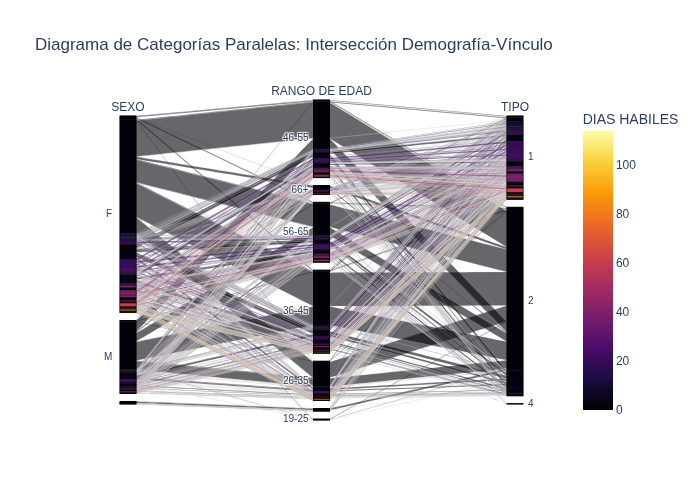

In [13]:
# 1. Parallel Categories Diagram: Flujo Demográfico y Administrativo
fig_para = px.parallel_categories(
    datos_total, 
    dimensions=["SEXO", "RANGO DE EDAD", "TIPO"],
    color="DIAS HABILES", 
    color_continuous_scale=px.colors.sequential.Inferno,
    title="Diagrama de Categorías Paralelas: Intersección Demografía-Vínculo"
)
fig_para.show()


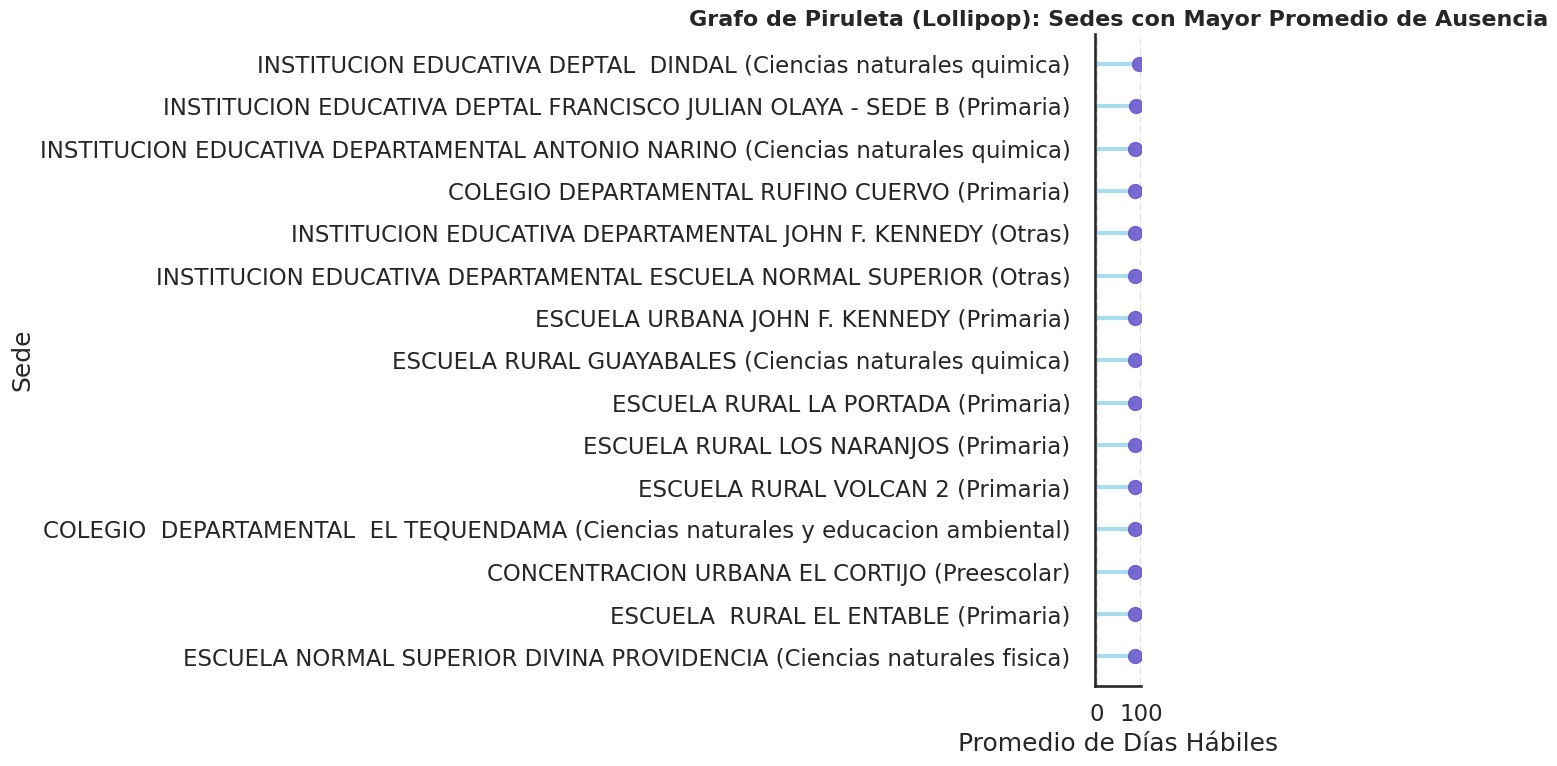

In [14]:
# 2. Lollipop Chart: Top 15 Sedes por Promedio de Días de Ausencia
sede_avg = datos_total.groupby("NOMBRE_SEDE")["DIAS HABILES"].mean().nlargest(15).reset_index()
sede_avg = sede_avg.sort_values("DIAS HABILES")

plt.figure(figsize=(12, 8))
plt.hlines(y=sede_avg["NOMBRE_SEDE"], xmin=0, xmax=sede_avg["DIAS HABILES"], color="skyblue", alpha=0.7, linewidth=3)
plt.plot(sede_avg["DIAS HABILES"], sede_avg["NOMBRE_SEDE"], "o", markersize=10, color="slateblue", alpha=0.9)

plt.title("Grafo de Piruleta (Lollipop): Sedes con Mayor Promedio de Ausencia", fontsize=16)
plt.xlabel("Promedio de Días Hábiles")
plt.ylabel("Sede")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


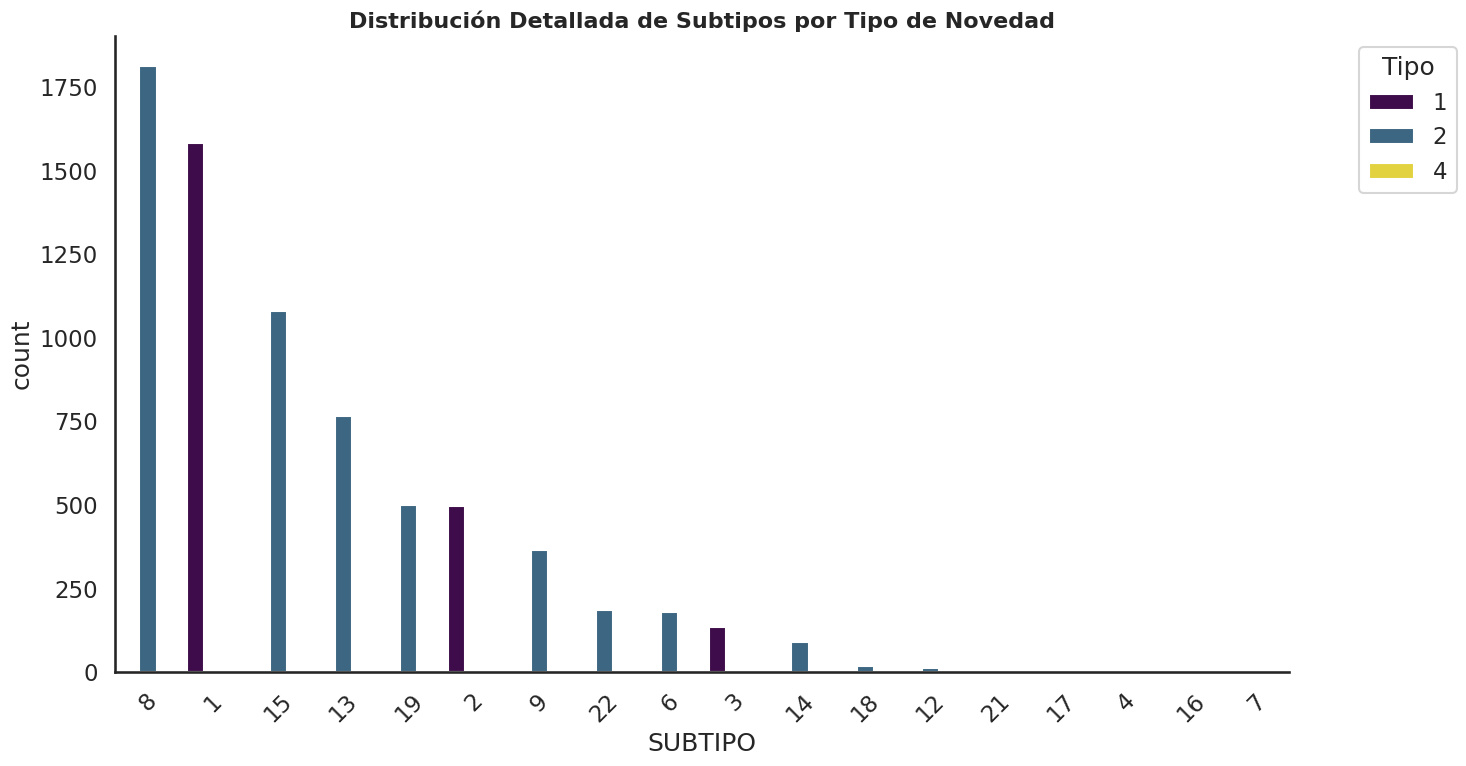

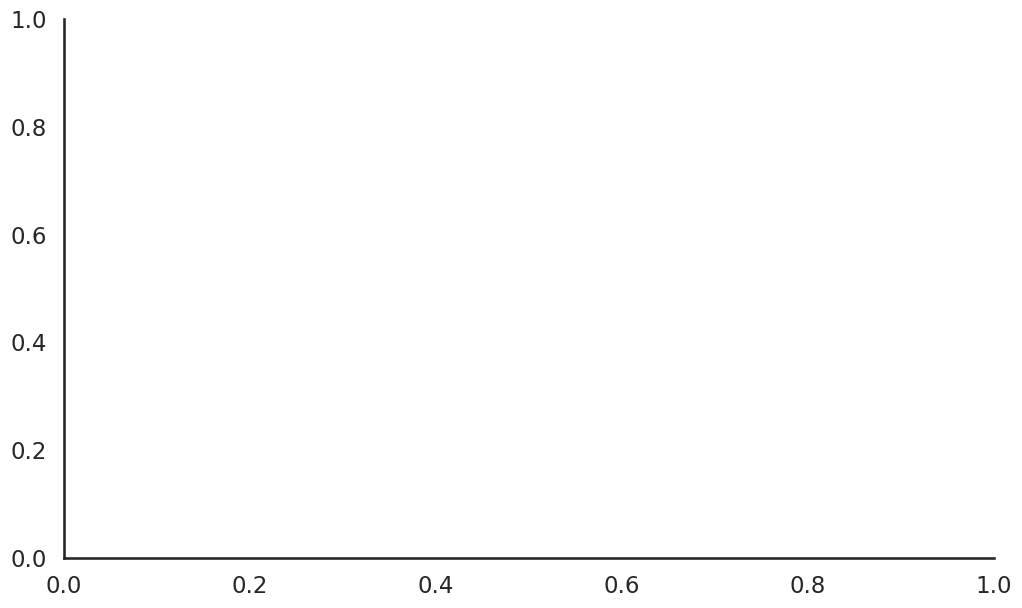

In [15]:
# Histograma Estilizado de Subtipos
plt.figure(figsize=(15, 8))
sns.countplot(data=datos_total, x='SUBTIPO', hue='TIPO', palette='viridis', order=datos_total['SUBTIPO'].value_counts().index)
plt.title('Distribución Detallada de Subtipos por Tipo de Novedad', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='Tipo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Agregar etiquetas de valor
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha="center", va="center", fontsize=11, color="black", xytext=(0, 7), textcoords="offset points")


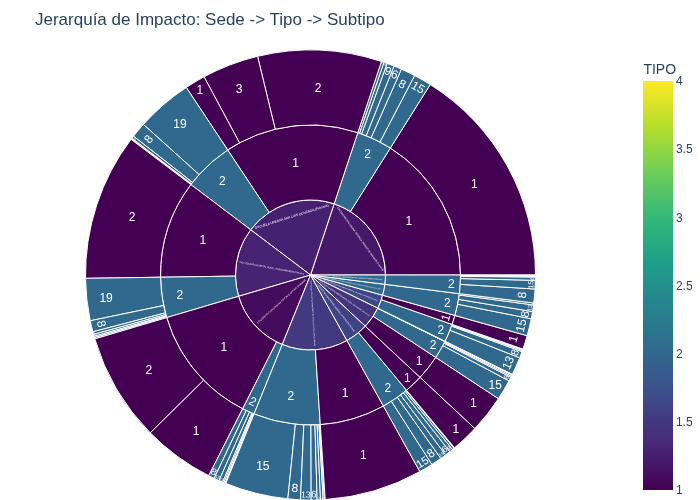

In [16]:
# 1. Sunburst Chart: Jerarquía Sede -> Tipo -> Subtipo
# Seleccionamos las sedes con más casos para evitar saturación
top_sedes = datos_total["NOMBRE_SEDE"].value_counts().nlargest(10).index
df_sunburst = datos_total[datos_total["NOMBRE_SEDE"].isin(top_sedes)]

fig_sun = px.sunburst(
    df_sunburst, 
    path=["NOMBRE_SEDE", "TIPO", "SUBTIPO"], 
    values="DIAS HABILES",
    color="TIPO",
    color_continuous_scale="Viridis",
    title="Jerarquía de Impacto: Sede -> Tipo -> Subtipo"
)
fig_sun.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig_sun.show()


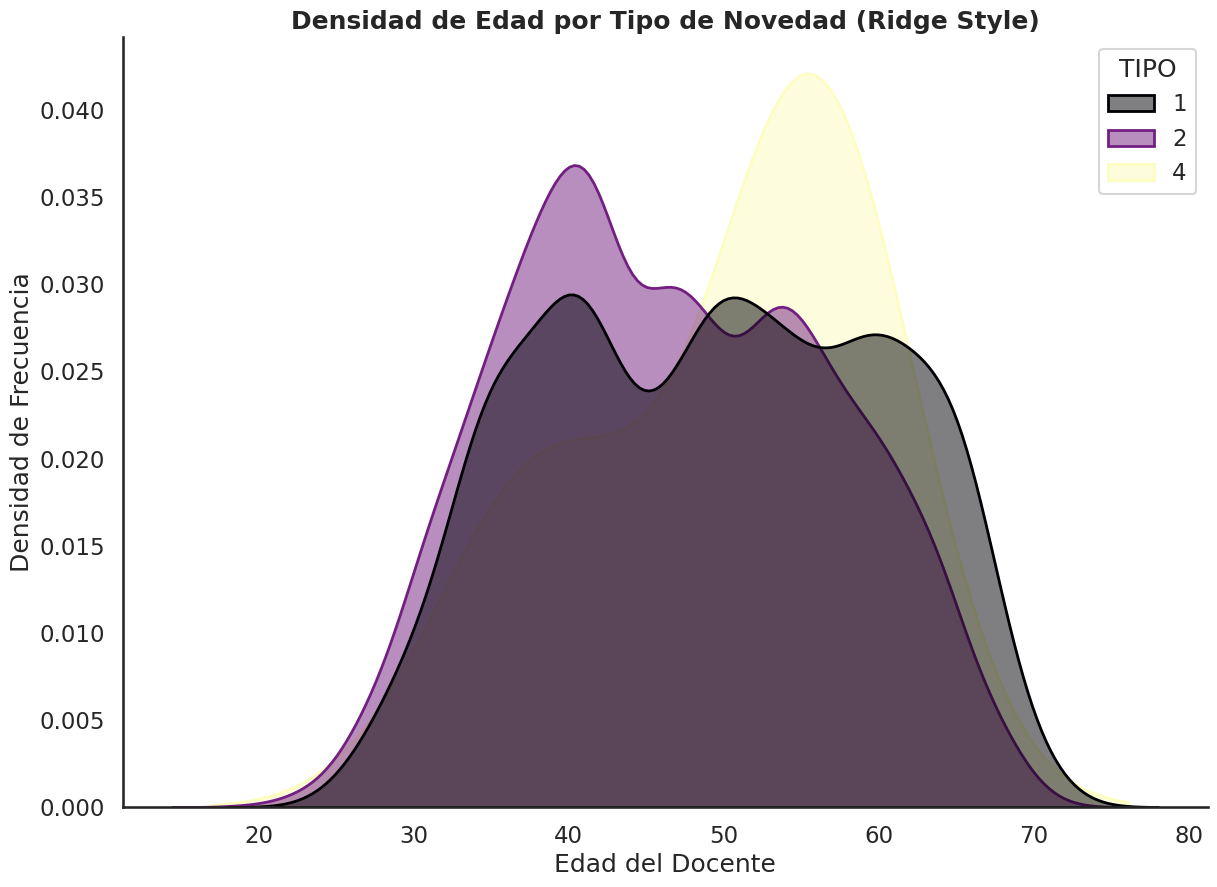

In [17]:
# 2. Ridge Plot: Distribución de Edad por Tipo de Novedad
plt.figure(figsize=(14, 10))
sns.kdeplot(
    data=datos_total, x="EDAD", hue="TIPO", 
    fill=True, common_norm=False, palette="magma", 
    alpha=.5, linewidth=2
)
plt.title("Densidad de Edad por Tipo de Novedad (Ridge Style)")
plt.xlabel("Edad del Docente")
plt.ylabel("Densidad de Frecuencia")
plt.show()


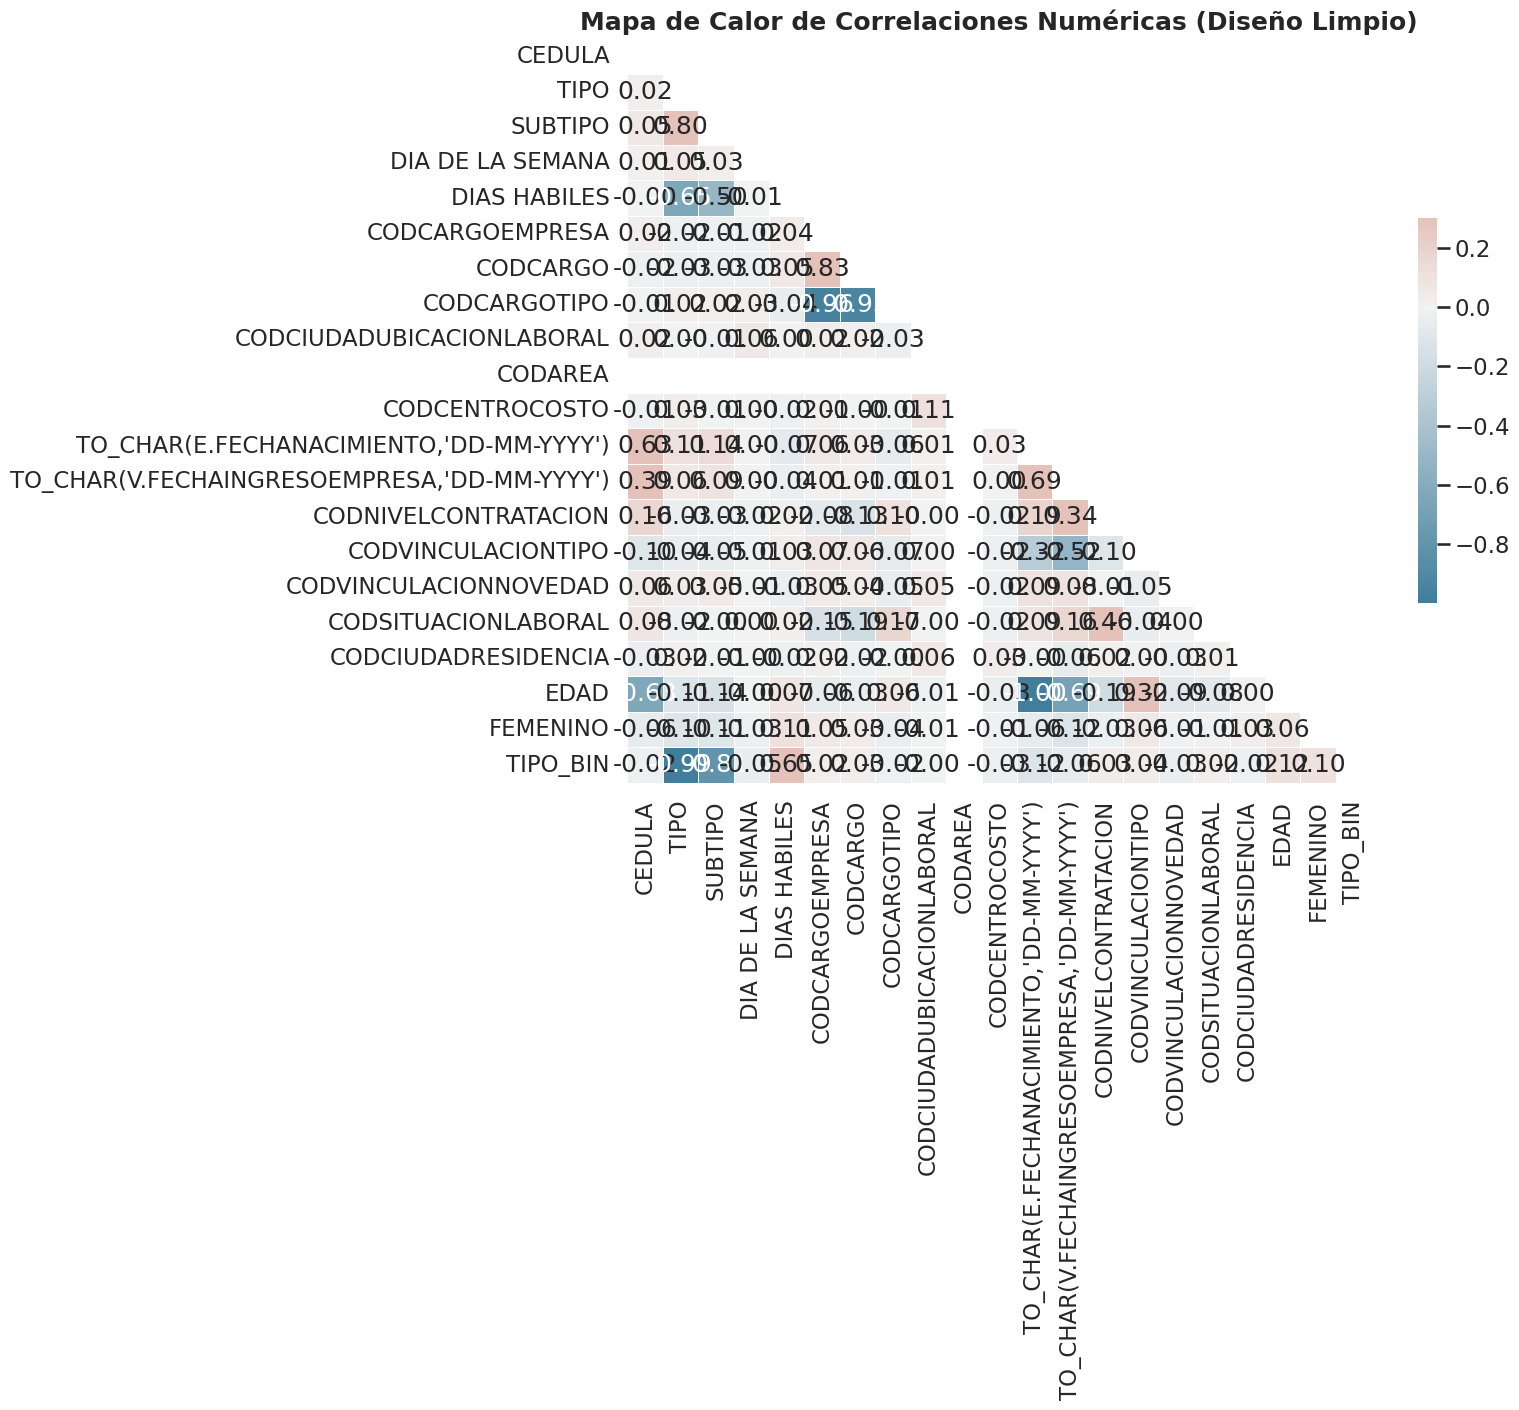

In [18]:
# 3. Stylized Heatmap de Correlaciones
corr = datos_total.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(12, 10))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr, mask=mask, cmap=cmap, vmax=.3, center=0,
    square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt=".2f"
)
plt.title("Mapa de Calor de Correlaciones Numéricas (Diseño Limpio)")
plt.show()


# 4. Segmentación Estratégica (MCA + Clustering)
Identificación de perfiles de riesgo y patrones multidimensionales.

In [19]:
datos2 = datos_total[['FECHA INICIAL', 'TIPO', 'SUBTIPO', 'EDAD', 'FEMENINO', 'RANGO DE EDAD']]
mca = prince.MCA()
mca.fit(datos2.drop('FECHA INICIAL', axis=1).astype(str))
# Obtener coordenadas para clustering
row_coords = mca.row_coordinates(datos2.drop("FECHA INICIAL", axis=1).astype(str))


In [20]:
# Segmentación de Usuarios (K-Means sobre MCA)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(row_coords)
datos_total['Cluster'] = clusters.astype(str)

print(f'Segmentación completada en {n_clusters} clusters.')


Segmentación completada en 4 clusters.


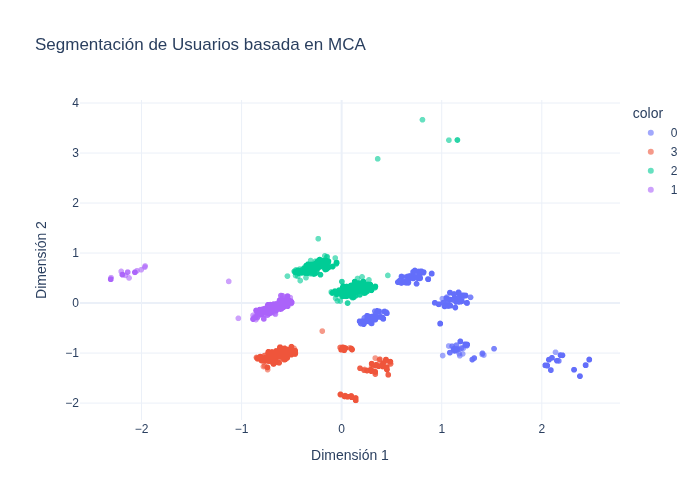

In [21]:
# Visualización de Clusters en 2D (MCA Dim 1 vs Dim 2)
fig_clusters = px.scatter(row_coords, x=0, y=1, color=datos_total['Cluster'],
                         title='Segmentación de Usuarios basada en MCA',
                         labels={'0': 'Dimensión 1', '1': 'Dimensión 2'},
                         template='plotly_white', opacity=0.6)
fig_clusters.show()


In [22]:
# Perfilado de Clusters: ¿Qué define a cada grupo?
cluster_profile = datos_total.groupby('Cluster')[['EDAD', 'TIPO', 'SUBTIPO']].agg(['mean', 'median'])
print('Perfil promedio de los clusters:')
display(cluster_profile)


Perfil promedio de los clusters:


EDAD             TIPO           SUBTIPO       
              mean median      mean median       mean median
Cluster                                                     
0        52.948969   53.0  1.052094    1.0   1.733912    1.0
1        40.144753   40.0  1.999413    2.0  12.331573   13.0
2        54.309659   54.0  2.004870    2.0  11.732549    9.0
3        32.524887   33.0  1.676895    2.0   9.175090    8.0

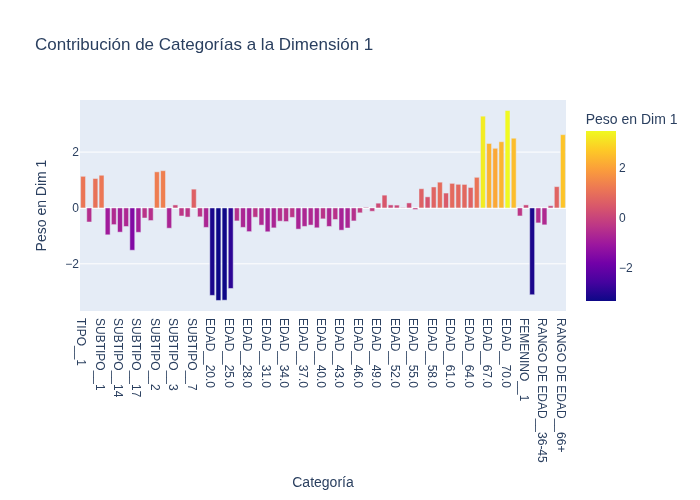

In [23]:
# Análisis de Contribuciones de Variables
col_coords = mca.column_coordinates(datos2.drop("FECHA INICIAL", axis=1).astype(str))
fig_contrib = px.bar(col_coords, y=0, x=col_coords.index, 
                     title='Contribución de Categorías a la Dimensión 1',
                     labels={'0': 'Peso en Dim 1', 'index': 'Categoría'},
                     color=col_coords[0])
fig_contrib.show()


# 5. Predicción y Proyección Temporal
Forecasting mensual del volumen de ausencias.

03:15:02 - cmdstanpy - INFO - Chain [1] start processing


03:15:02 - cmdstanpy - INFO - Chain [1] done processing


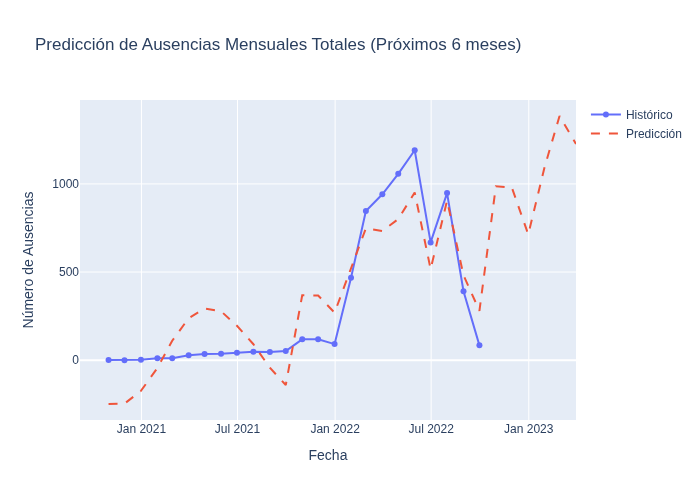

In [24]:
# 1. Agregación de datos por mes para Predicción de Volumen Total
df_time = datos_total.copy()
df_time['DS'] = pd.to_datetime(df_time['FECHA INICIAL'])
df_monthly = df_time.set_index('DS').resample('ME').size().reset_index()
df_monthly.columns = ['ds', 'y']

# Modelo Prophet para series temporales
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(df_monthly)

# Predicción para los próximos 6 meses
future = m.make_future_dataframe(periods=6, freq='ME')
forecast = m.predict(future)

fig_forecast = go.Figure()
fig_forecast.add_trace(go.Scatter(x=df_monthly['ds'], y=df_monthly['y'], name='Histórico', mode='markers+lines'))
fig_forecast.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'], name='Predicción', line=dict(dash='dash')))
fig_forecast.update_layout(title='Predicción de Ausencias Mensuales Totales (Próximos 6 meses)', xaxis_title='Fecha', yaxis_title='Número de Ausencias')
fig_forecast.show()


# 6. Análisis Profundo de Recurrencia e Impacto
Impacto por sede, recurrencia y asociaciones complejas.

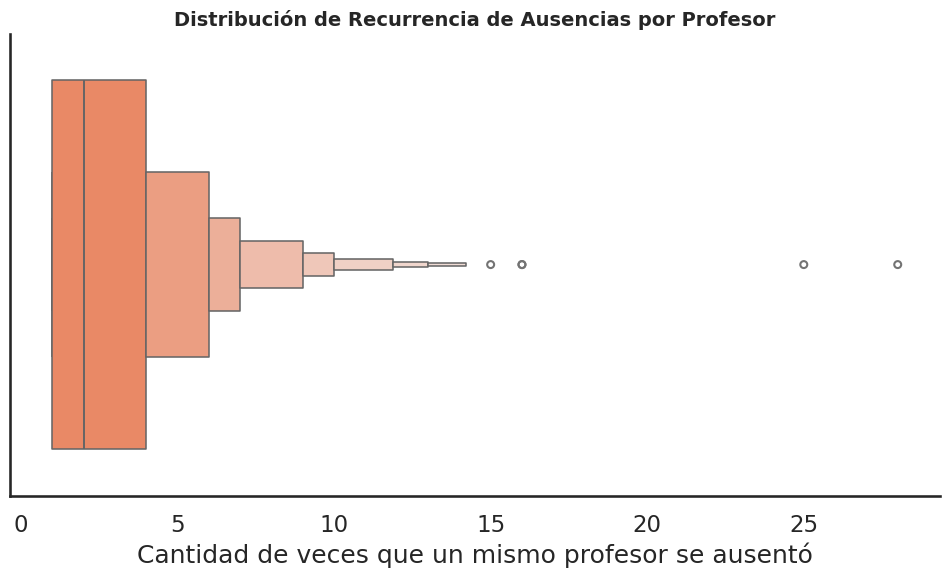

In [25]:
# 1. Análisis de Recurrencia: ¿Quiénes se ausentan más veces?
recurrencia = datos_total['CEDULA'].value_counts().reset_index()
recurrencia.columns = ['ID_Profesor', 'Numero_Ausencias']

plt.figure(figsize=(12, 6))
sns.boxenplot(data=recurrencia, x='Numero_Ausencias', color='coral')
plt.title('Distribución de Recurrencia de Ausencias por Profesor', fontsize=14)
plt.xlabel('Cantidad de veces que un mismo profesor se ausentó')
plt.show()


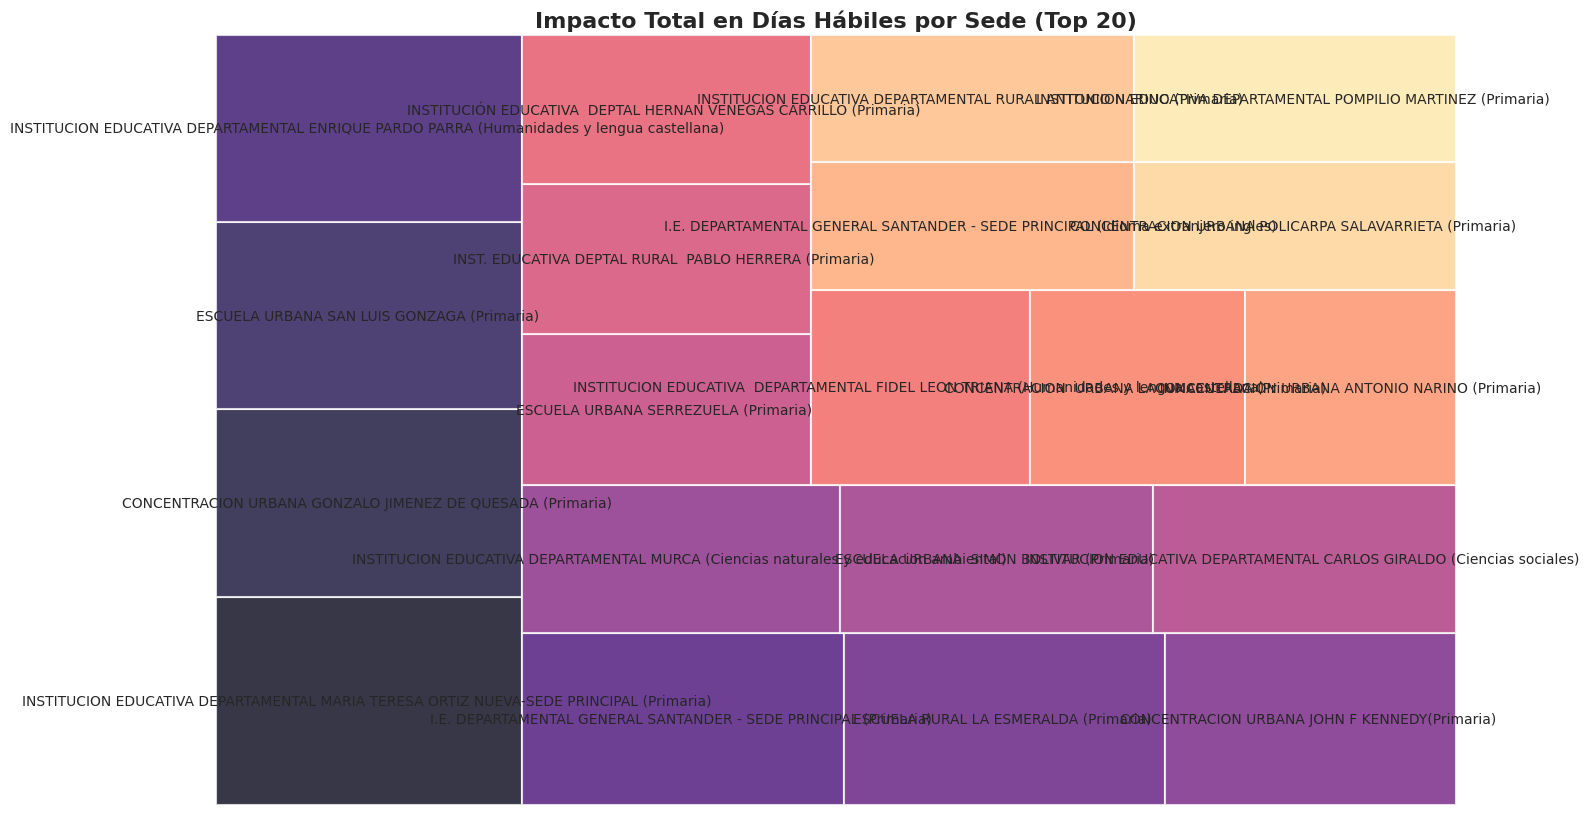

In [26]:
# 2. Treemap Profundo de Sedes y Días Perdidos
sede_impact = datos_total.groupby('NOMBRE_SEDE')['DIAS HABILES'].sum().reset_index()
sede_impact = sede_impact.sort_values(by='DIAS HABILES', ascending=False).head(20)

plt.figure(figsize=(16, 10))
squarify.plot(sizes=sede_impact['DIAS HABILES'], label=sede_impact['NOMBRE_SEDE'], 
              alpha=.8, color=sns.color_palette('magma', len(sede_impact)), text_kwargs={'fontsize':10})
plt.title('Impacto Total en Días Hábiles por Sede (Top 20)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()


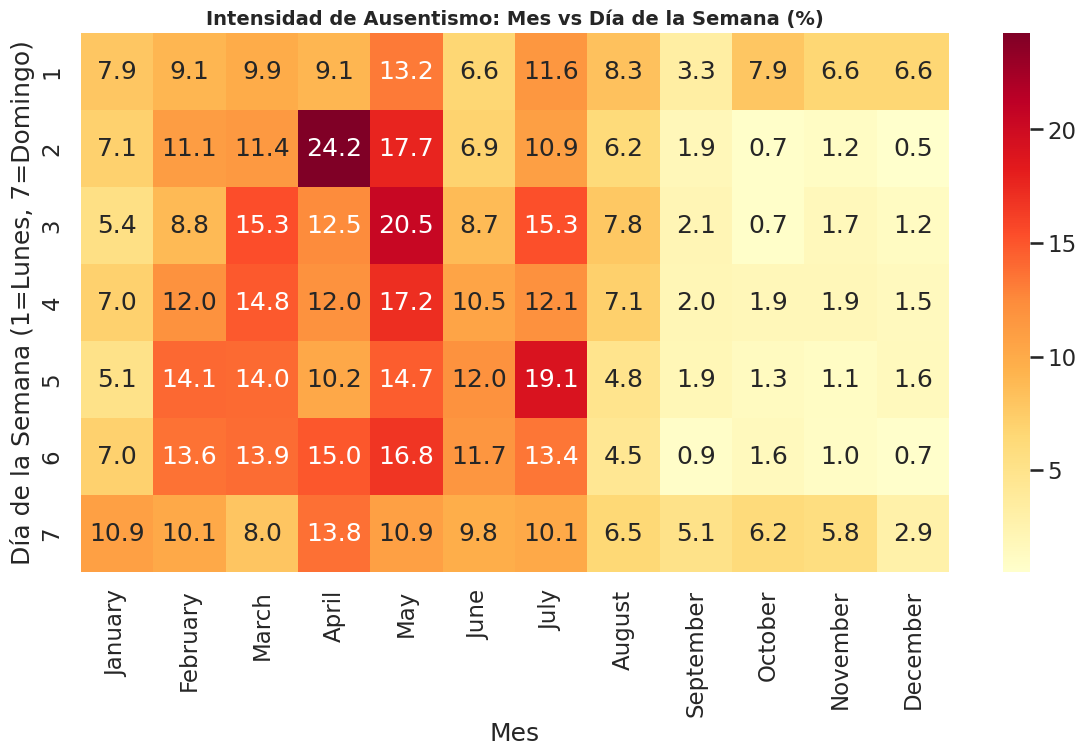

In [27]:
# 3. Análisis de Pico Temporal: Estacionalidad Mensual
import calendar
month_order = list(calendar.month_name)[1:]
datos_total["Mes_Nombre"] = datos_total["FECHA INICIAL"].dt.month_name()

temp_map = pd.crosstab(datos_total["DIA DE LA SEMANA"], 
                       datos_total["Mes_Nombre"],
                       normalize="index") * 100

# Reordenar columnas para que los meses sigan orden cronológico
existing_months = [m for m in month_order if m in temp_map.columns]
temp_map = temp_map[existing_months]

plt.figure(figsize=(14, 7))
sns.heatmap(temp_map, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Intensidad de Ausentismo: Mes vs Día de la Semana (%)", fontsize=14)
plt.ylabel("Día de la Semana (1=Lunes, 7=Domingo)")
plt.xlabel("Mes")
plt.show()


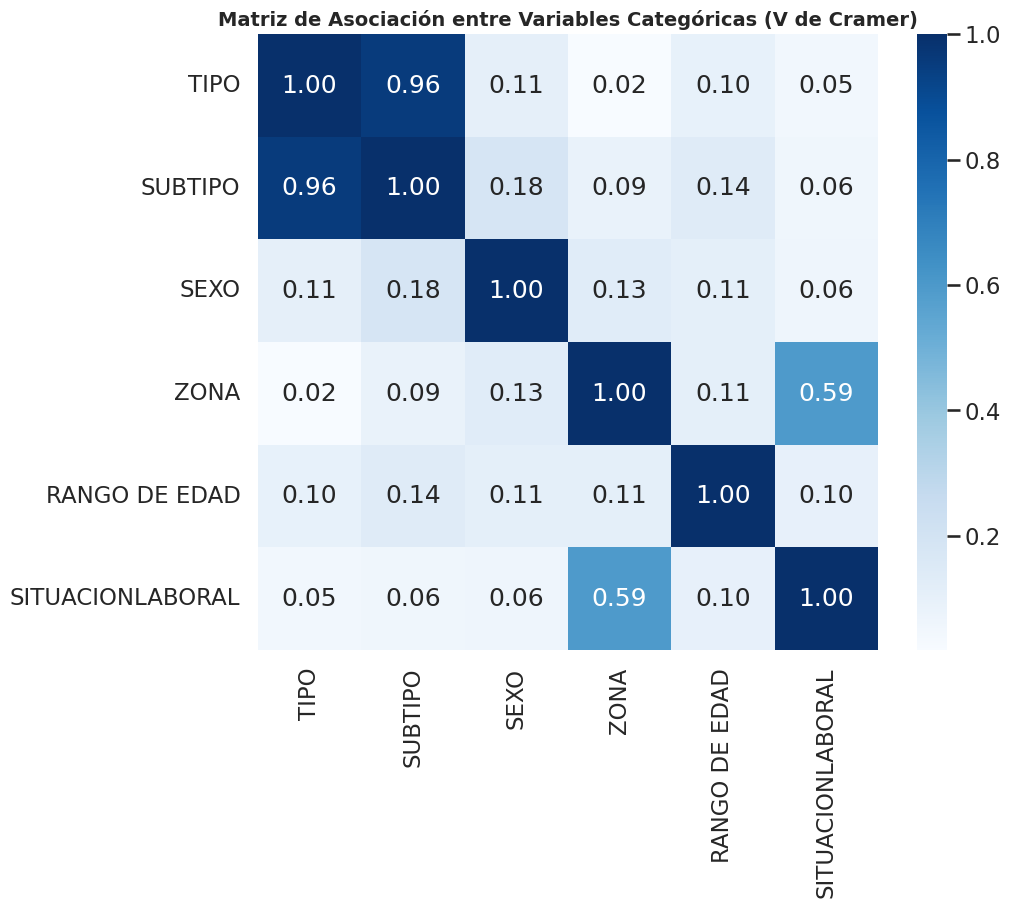

In [28]:
# 4. Análisis de Correlación de Categorías (Heatmap de Cramer's V)
from scipy.stats import chi2_contingency
def cramers_v_matrix(df):
    cols = df.columns
    n = len(df)
    matrix = np.zeros((len(cols), len(cols)))
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j: matrix[i,j] = 1; continue
            tab = pd.crosstab(df[cols[i]], df[cols[j]])
            if tab.size == 0 or n == 0 or min(tab.shape) <= 1:
                matrix[i,j] = 0
                continue
            chi2 = chi2_contingency(tab)[0]
            matrix[i,j] = np.sqrt(chi2 / (n * (min(tab.shape)-1)))
    return pd.DataFrame(matrix, index=cols, columns=cols)

cat_cols = ['TIPO', 'SUBTIPO', 'SEXO', 'ZONA', 'RANGO DE EDAD', 'SITUACIONLABORAL']
cv_mat = cramers_v_matrix(datos_total[cat_cols].astype(str))

plt.figure(figsize=(10, 8))
sns.heatmap(cv_mat, annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriz de Asociación entre Variables Categóricas (V de Cramer)', fontsize=14)
plt.show()


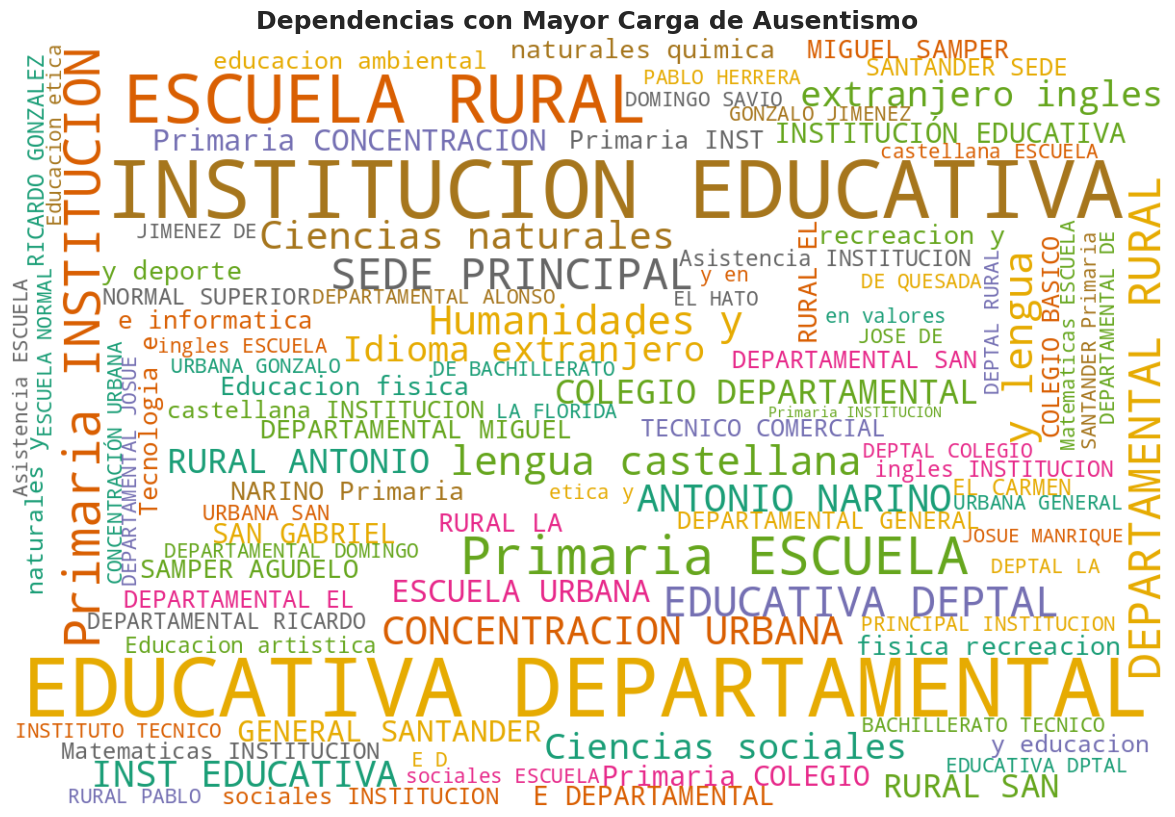

In [29]:
# 5. Análisis de Frecuencia de Dependencias (WordCloud)
text = " ".join(str(dep) for dep in datos_total.DEPENDENCIA if pd.notnull(dep))
wordcloud = WordCloud(width=1200, height=800, background_color="white", colormap="Dark2", max_words=100).generate(text)
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Dependencias con Mayor Carga de Ausentismo", fontsize=18)
plt.axis("off")
plt.show()


# 7. Modelos Avanzados de Riesgo y Visualizaciones de Élite
Detección de anomalías, scoring y diagramas de flujo sistémico.

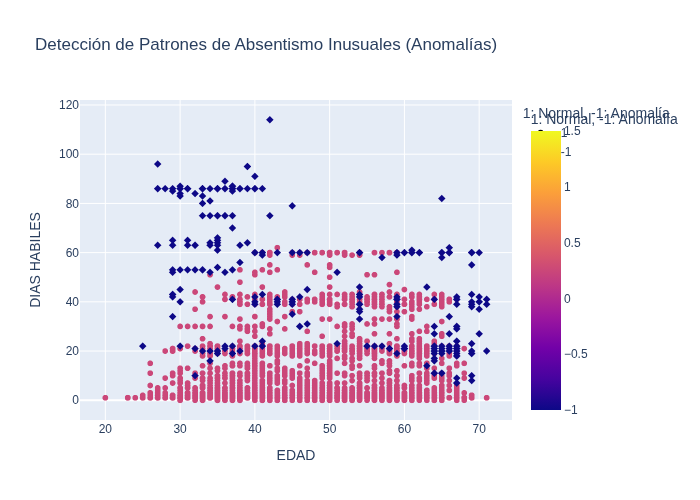

In [30]:
# 1. Detección de Anomalías (Isolation Forest)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_anom = datos_total[['EDAD', 'DIAS HABILES', 'FEMENINO']].fillna(0)
datos_total['Anomaly'] = iso_forest.fit_predict(df_anom)

fig_anom = px.scatter(datos_total, x='EDAD', y='DIAS HABILES', color='Anomaly', 
                     symbol='Anomaly', title='Detección de Patrones de Absentismo Inusuales (Anomalías)',
                     labels={'Anomaly': '1: Normal, -1: Anomalía'},
                     color_discrete_map={'1': 'blue', '-1': 'red'})
fig_anom.show()


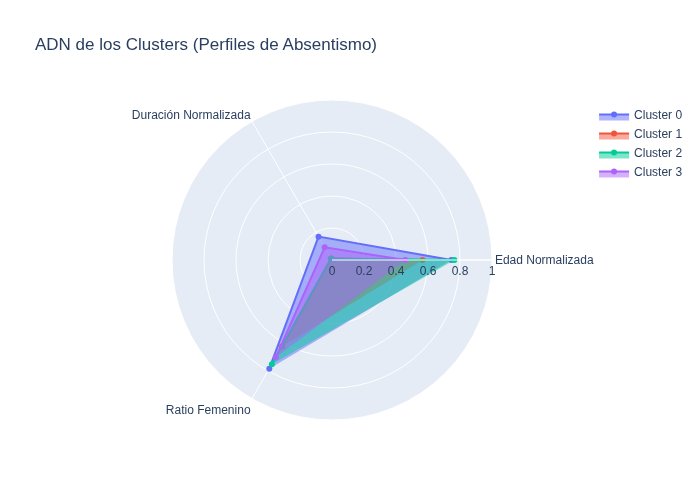

In [31]:
# 2. Perfiles de Cluster en Gráfico de Radar (Plotly)
cluster_means = datos_total.groupby('Cluster')[['EDAD', 'DIAS HABILES', 'FEMENINO']].mean().reset_index()
fig_radar = go.Figure()

for i, row in cluster_means.iterrows():
    fig_radar.add_trace(go.Scatterpolar(
        r=[row['EDAD']/datos_total['EDAD'].max(), row['DIAS HABILES']/datos_total['DIAS HABILES'].max(), row['FEMENINO']],
        theta=['Edad Normalizada', 'Duración Normalizada', 'Ratio Femenino'],
        fill='toself', name=f'Cluster {row["Cluster"]}'
    ))

fig_radar.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])), 
                        title='ADN de los Clusters (Perfiles de Absentismo)')
fig_radar.show()


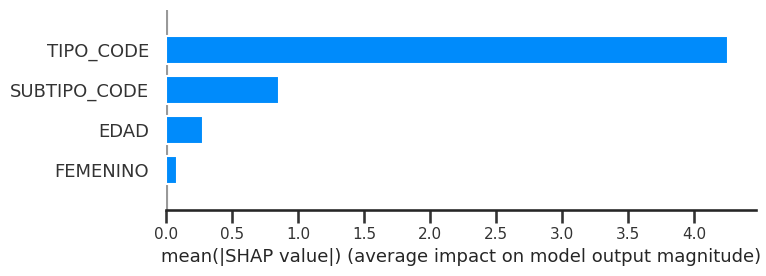

In [32]:
# 2. Inteligencia Artificial Explicable (SHAP)
model, explainer, shap_values, X_test, features = train_risk_model(datos_total)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.show()


In [33]:
# 3. Reporte de Riesgo Individual (Probabilidad Predictiva)
# Usamos el modelo XGBoost entrenado anteriormente para asignar una probabilidad de riesgo real
features_full = datos_total[["EDAD", "FEMENINO", "TIPO", "SUBTIPO"]].copy()
features_full["TIPO_CODE"] = LabelEncoder().fit_transform(features_full["TIPO"].astype(str))
features_full["SUBTIPO_CODE"] = LabelEncoder().fit_transform(features_full["SUBTIPO"].astype(str))
X_full = features_full[["EDAD", "FEMENINO", "TIPO_CODE", "SUBTIPO_CODE"]]

# Predicción de Probabilidad
datos_total["Probabilidad_Riesgo"] = model.predict_proba(X_full)[:, 1]

# Agrupación por docente para el reporte final
reporte_final = datos_total.groupby("CEDULA").agg({
    "Probabilidad_Riesgo": "max",
    "DIAS HABILES": "sum",
    "TIPO": "count"
}).rename(columns={"DIAS HABILES": "Dias_Acumulados", "TIPO": "Eventos"}).sort_values("Probabilidad_Riesgo", ascending=False).head(10).reset_index()

# Renderizado de Tabla Élite
html_table = '<table class="data-table"><thead><tr><th>ID Docente</th><th>Prob. Riesgo (%)</th><th>Días Totales</th><th>Frecuencia</th></tr></thead><tbody>'
for _, row in reporte_final.iterrows():
    prob_fmt = f'{row["Probabilidad_Riesgo"]*100:.1f}%'
    html_table += f'<tr><td>{row["CEDULA"]}</td><td><b style="color:#e67e22">{prob_fmt}</b></td><td>{row["Dias_Acumulados"]:.0f}</td><td>{row["Eventos"]}</td></tr>'
html_table += "</tbody></table>"

display(HTML(html_table))
show_insight("La probabilidad predictiva utiliza XGBoost para estimar el riesgo de que un docente supere los 5 días de ausencia basado en su perfil demográfico y administrativo.")


ID Docente,Prob. Riesgo (%),Días Totales,Frecuencia
52412259.0,99.4%,79,1.0
1077032499.0,99.4%,126,4.0
1014186400.0,99.4%,62,9.0
1074414802.0,99.4%,84,2.0
1032396164.0,99.4%,30,1.0
1069282232.0,99.4%,86,1.0
1078346463.0,99.4%,64,1.0
1069718725.0,99.4%,86,2.0
40043845.0,99.4%,115,2.0
52602681.0,99.4%,94,9.0


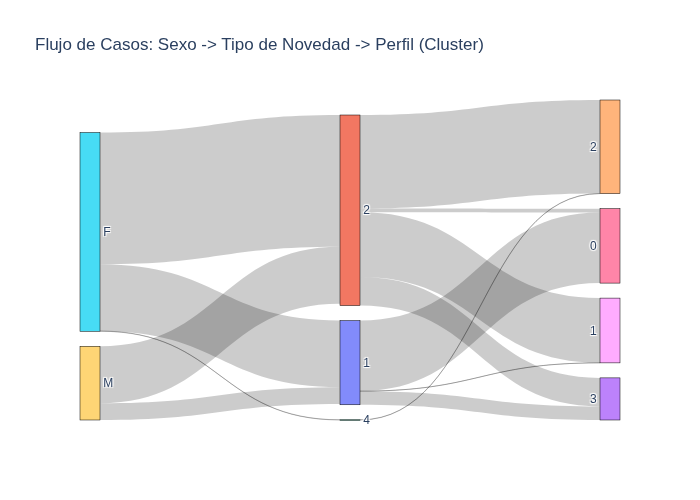

In [34]:
# 2. Sankey Diagram: Flujo de Absentismo por Sexo, Tipo y Cluster
def make_sankey(df, cols):
    labels = []
    for col in cols: labels.extend(df[col].unique().tolist())
    labels = list(set(labels))
    label_map = {l: i for i, l in enumerate(labels)}
    
    sources, targets, values = [], [], []
    for i in range(len(cols)-1):
        s_col, t_col = cols[i], cols[i+1]
        counts = df.groupby([s_col, t_col]).size().reset_index(name='count')
        sources.extend([label_map[s] for s in counts[s_col]])
        targets.extend([label_map[t] for t in counts[t_col]])
        values.extend(counts['count'])
    
    return go.Figure(data=[go.Sankey(
        node = dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=labels),
        link = dict(source=sources, target=targets, value=values)
    )])

fig_sankey = make_sankey(datos_total, ['SEXO', 'TIPO', 'Cluster'])
fig_sankey.update_layout(title_text="Flujo de Casos: Sexo -> Tipo de Novedad -> Perfil (Cluster)", font_size=12)
fig_sankey.show()


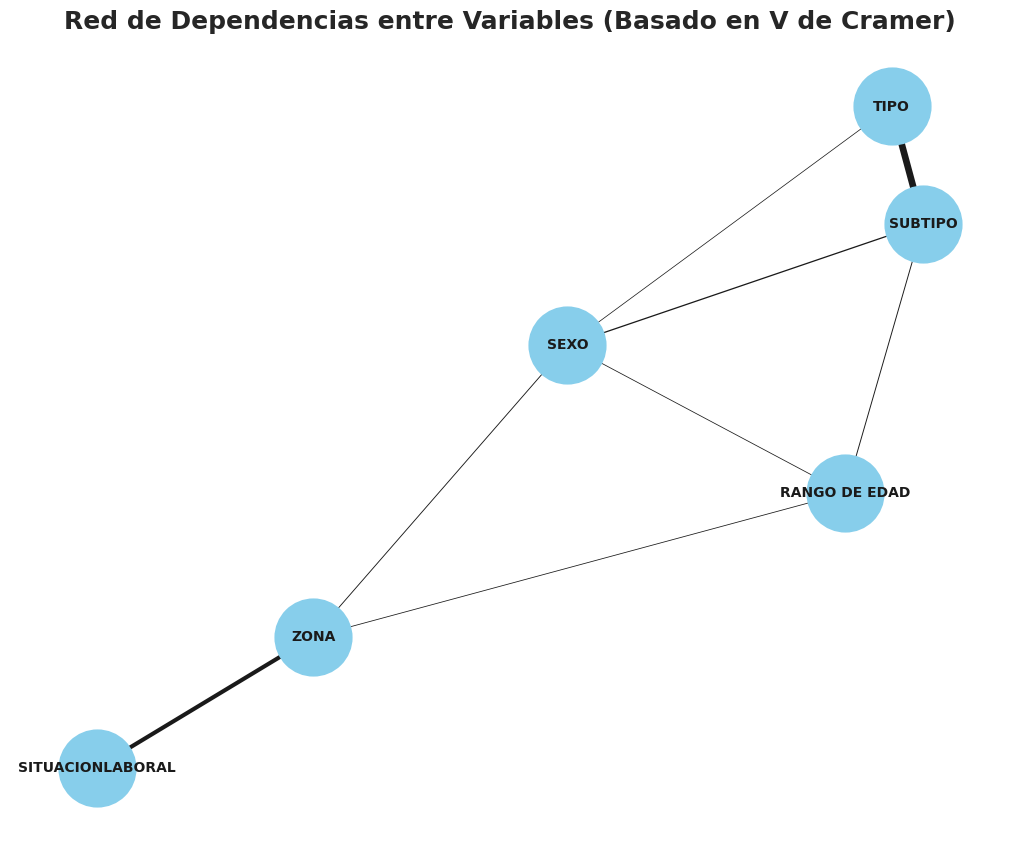

In [35]:
# 3. Network Graph: Red de Asociaciones Categóricas
# Usamos la matriz de Cramer's V calculada anteriormente (cv_mat)
G = nx.Graph()
for i in range(len(cv_mat.columns)):
    for j in range(i+1, len(cv_mat.columns)):
        weight = cv_mat.iloc[i, j]
        if weight > 0.1: # Solo conexiones significativas
            G.add_edge(cv_mat.columns[i], cv_mat.columns[j], weight=weight)

pos = nx.spring_layout(G)
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000, font_size=10, font_weight='bold', 
        width=[G[u][v]['weight']*5 for u,v in G.edges()])
plt.title("Red de Dependencias entre Variables (Basado en V de Cramer)")
plt.show()


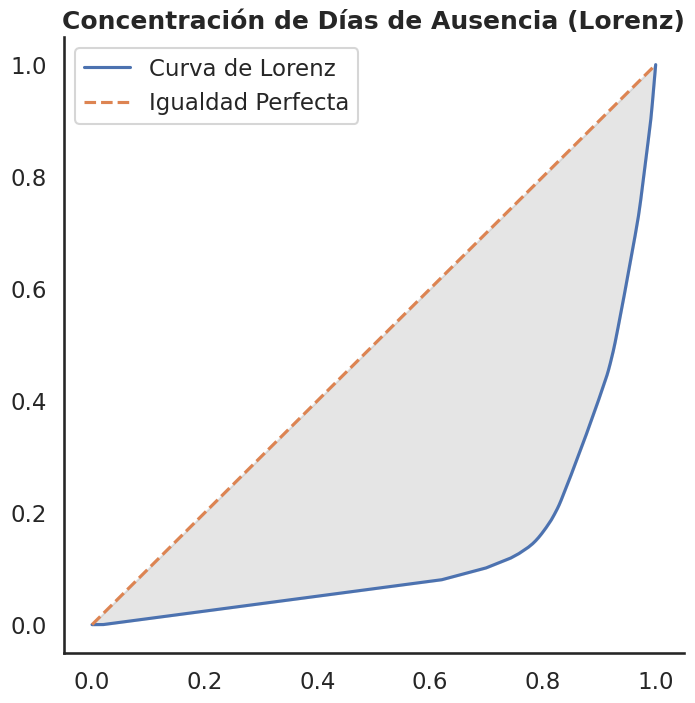

In [36]:
# 4. Curva de Concentración (Lorenz) de Días de Absentismo
def plot_lorenz(values, title):
    n = len(values)
    scaled_prefix_sum = np.cumsum(np.sort(values)) / np.sum(values)
    lorenz_curve = np.insert(scaled_prefix_sum, 0, 0)
    plt.figure(figsize=(8, 8))
    plt.plot(np.linspace(0, 1, n + 1), lorenz_curve, label='Curva de Lorenz')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Igualdad Perfecta')
    plt.fill_between(np.linspace(0, 1, n + 1), np.linspace(0, 1, n + 1), lorenz_curve, color='gray', alpha=0.2)
    plt.title(title)
    plt.legend()
    plt.show()

plot_lorenz(datos_total['DIAS HABILES'].values, "Concentración de Días de Ausencia (Lorenz)")


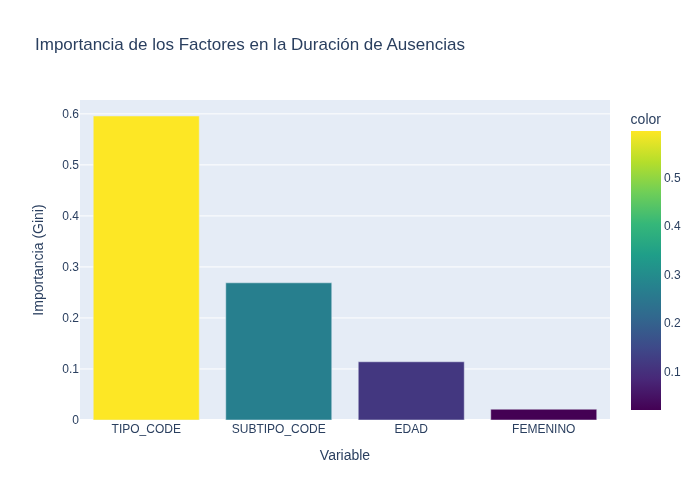

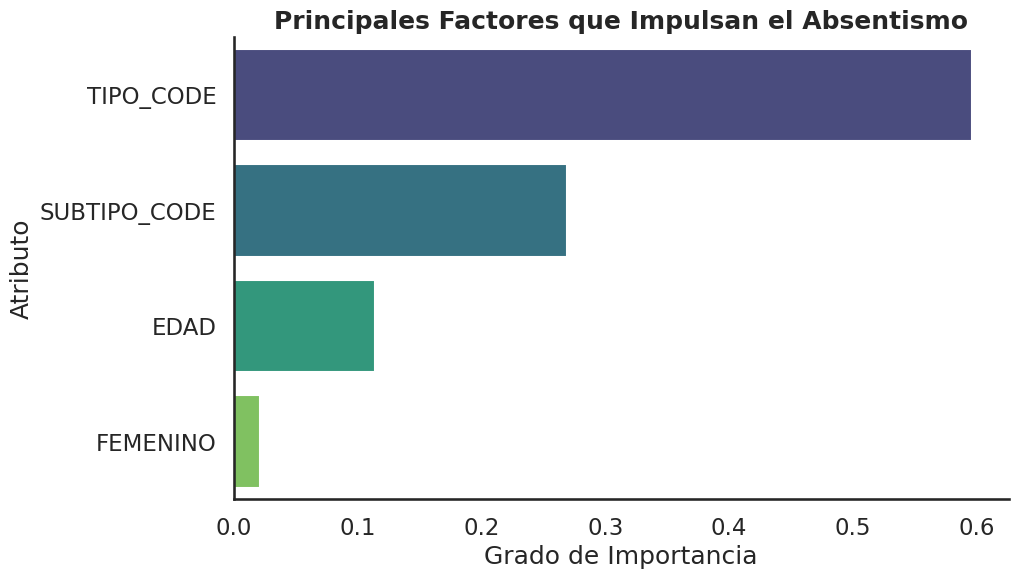

In [37]:
# 3. Modelo Predictivo de Riesgo Individual (Factores Clave)
from sklearn.preprocessing import LabelEncoder
df_model = datos_total[['EDAD', 'FEMENINO', 'TIPO', 'SUBTIPO', 'DIAS HABILES']].dropna().copy()

# Codificación de variables categóricas para Random Forest
le = LabelEncoder()
df_model['TIPO_CODE'] = le.fit_transform(df_model['TIPO'].astype(str))
df_model['SUBTIPO_CODE'] = le.fit_transform(df_model['SUBTIPO'].astype(str))

X = df_model[['EDAD', 'FEMENINO', 'TIPO_CODE', 'SUBTIPO_CODE']]
y = df_model['DIAS HABILES']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Definir importancia
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visualización Plotly
fig_imp = px.bar(importance, title='Importancia de los Factores en la Duración de Ausencias',
                 labels={'value': 'Importancia (Gini)', 'index': 'Variable'},
                 color=importance.values, color_continuous_scale='Viridis')
fig_imp.show()

# Visualización Seaborn con Diseño Mejorado
plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, hue=importance.index, palette="viridis", legend=False)
plt.title("Principales Factores que Impulsan el Absentismo")
plt.xlabel("Grado de Importancia")
plt.ylabel("Atributo")
plt.show()


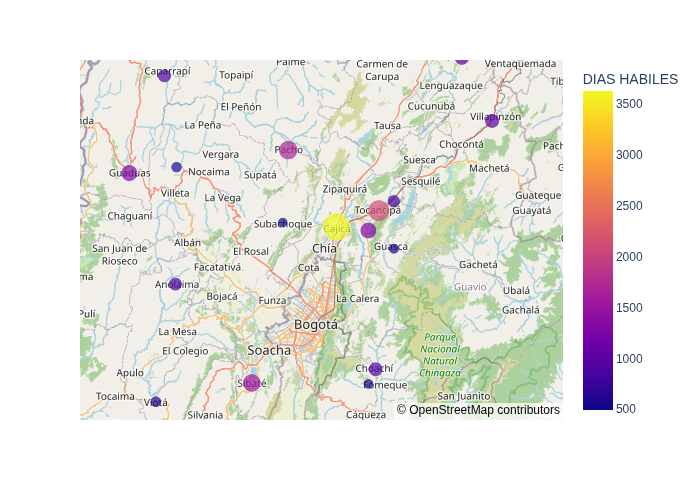

In [38]:
# 3. Análisis Geográfico
geo_data = datos_total.groupby("CIUDAD")["DIAS HABILES"].sum().reset_index()
geo_data["City"] = geo_data["CIUDAD"].apply(clean_city_name)
coords = get_city_coords()
geo_data["lat"] = geo_data["City"].map(lambda x: coords.get(x, [None,None])[0])
geo_data["lon"] = geo_data["City"].map(lambda x: coords.get(x, [None,None])[1])
fig_geo = px.scatter_mapbox(geo_data.dropna(), lat="lat", lon="lon", size="DIAS HABILES", color="DIAS HABILES")
fig_geo.update_layout(mapbox_style="open-street-map")
fig_geo.show()
